In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [3]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [4]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [5]:
protons = protons[(protons['height'] < 100) & (protons['width'] < 400)]
deuterons = deuterons[(deuterons['height'] < 100) & (deuterons['width'] < 400)]

In [6]:
protons.shape, deuterons.shape

((6291, 37), (5115, 37))

In [7]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(399, 99, 399, 99)

In [8]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

<Axes: >

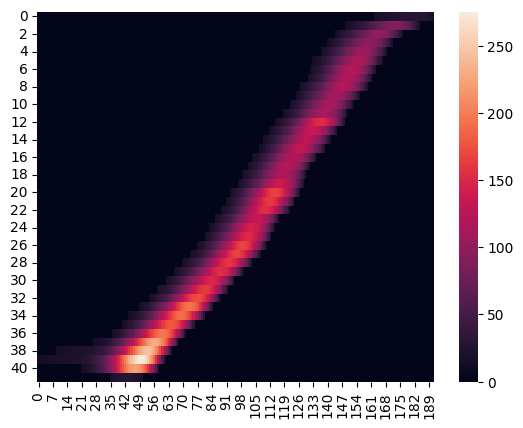

In [9]:
i = 14
sns.heatmap(protons['image_intensity'].iloc[i])

In [10]:
int(np.argmax(protons['image_intensity'].iloc[i][0]))

180

In [11]:
pv = []                                                 # vertex
pe = []                                                 # end   
for idx, row in protons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    pv.append(vertex)
    pe.append(end)

pv = np.array(pv)
pe = np.array(pe)

dv = []                                                 # vertex
de = []                                                 # end   
for idx, row in deuterons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    dv.append(vertex)
    de.append(end)

np.int64(-348)

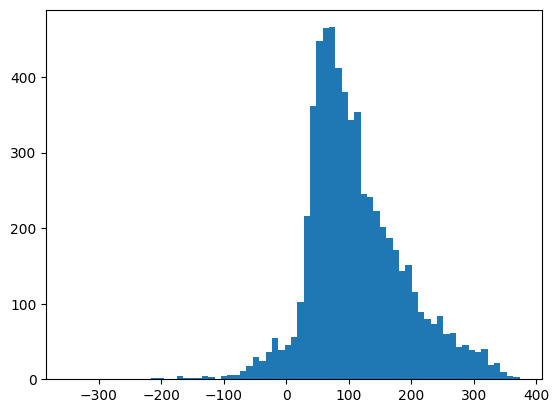

In [12]:
plt.hist(pv - pe, bins='auto')
min(pv-pe)

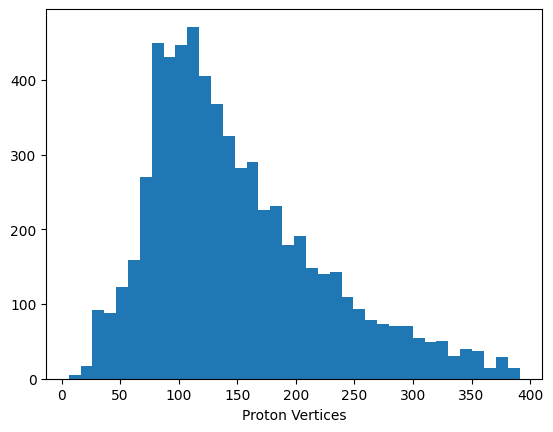

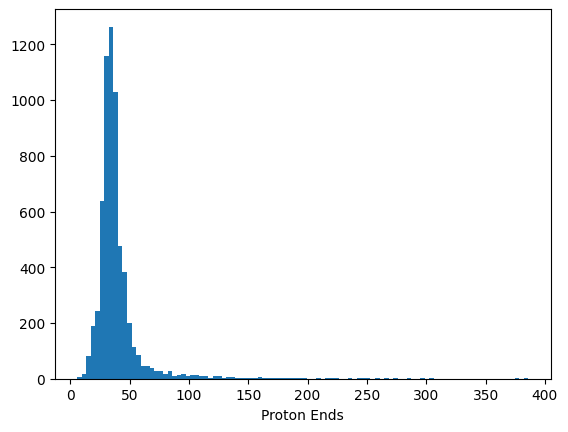

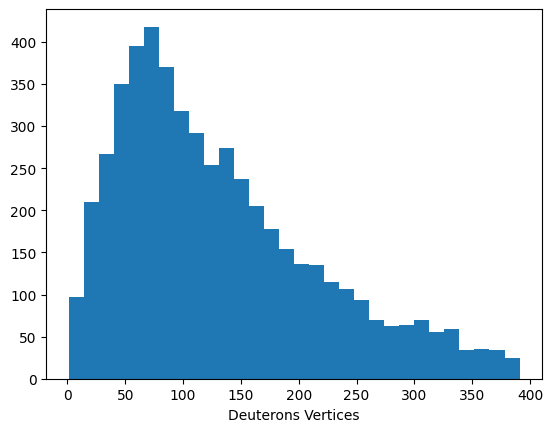

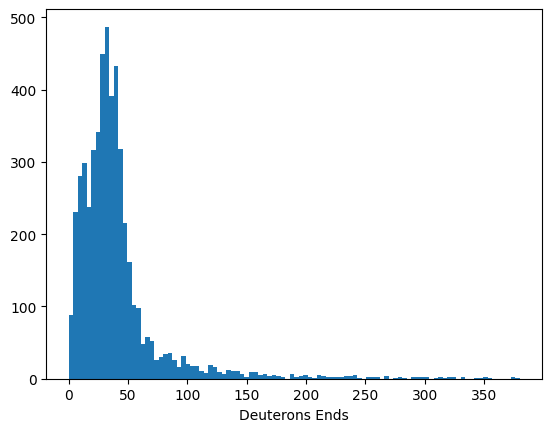

In [13]:
plt.hist(pv, bins='auto'); plt.xlabel('Proton Vertices'); plt.show()
plt.hist(pe, bins=100); plt.xlabel('Proton Ends'); plt.show()
plt.hist(dv, bins='auto'); plt.xlabel('Deuterons Vertices'); plt.show()
plt.hist(de, bins=100); plt.xlabel('Deuterons Ends'); plt.show()

<Axes: >

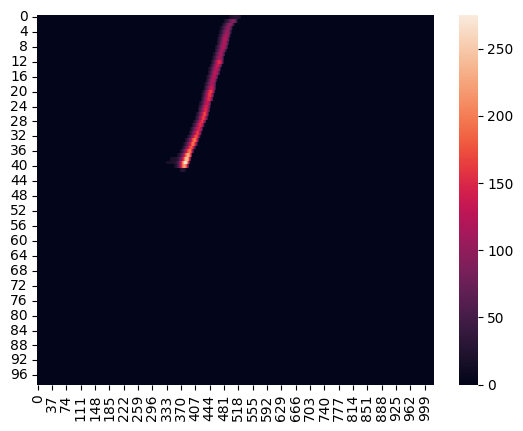

In [14]:
pad = pad_image(protons['image_intensity'].iloc[i])
sns.heatmap(pad)

In [15]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [16]:
p = [] 
d = []

for idx, row in protons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    p.append(padded)

for idx, row in deuterons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    d.append(padded)

p = np.array(p)
d = np.array(d)

p_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p])
d_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d])

In [17]:
imgpv = []                                                 # vertex
imgpe = []                                                 # end   
for img in p_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgpv.append(vertex)
    imgpe.append(end)

imgdv = []                                                 # vertex
imgde = []                                                 # end   
for img in d_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgdv.append(vertex)
    imgde.append(end)

0


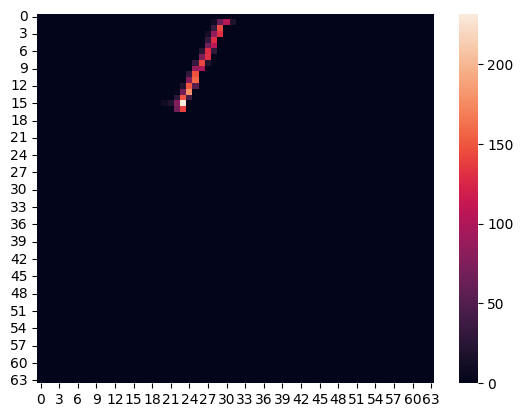

In [18]:
i = 2
sns.heatmap(p_d[i]); print(np.argmax(p_d[i][0]))

<Axes: >

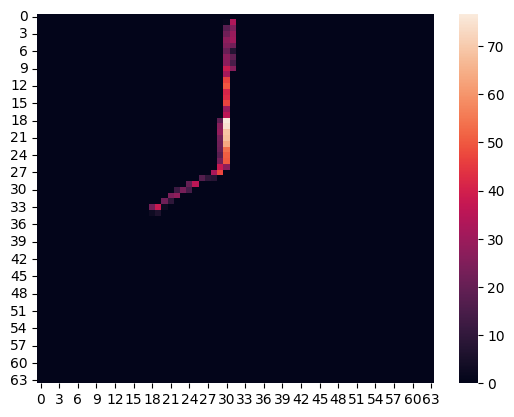

In [19]:
sns.heatmap(d_d[3])

In [20]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [27]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p_d, dtype=torch.float32)  # shape (N, H, W)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 50
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_d_d = []

Training device: mps



===== Fold 1/5 =====
Epoch 1/50: Train=57.0858, Val=33.2102
Epoch 2/50: Train=27.0924, Val=22.1891
Epoch 3/50: Train=19.4461, Val=17.0966
Epoch 4/50: Train=15.8741, Val=15.9106
Epoch 5/50: Train=14.0866, Val=14.3580
Epoch 6/50: Train=12.3031, Val=11.9796
Epoch 7/50: Train=10.9863, Val=10.8686
Epoch 8/50: Train=10.4014, Val=11.1001
Epoch 9/50: Train=9.5491, Val=10.5003
Epoch 10/50: Train=8.8918, Val=9.9025
Epoch 11/50: Train=8.3635, Val=9.9715
Epoch 12/50: Train=8.0695, Val=8.7130
Epoch 13/50: Train=7.5542, Val=8.8940
Epoch 14/50: Train=7.4443, Val=8.4530
Epoch 15/50: Train=6.8599, Val=8.6329
Epoch 16/50: Train=6.8191, Val=9.1028
Epoch 17/50: Train=6.6947, Val=7.5606
Epoch 18/50: Train=6.1989, Val=7.8302
Epoch 19/50: Train=6.4323, Val=7.4870
Epoch 20/50: Train=5.8461, Val=7.1036
Epoch 21/50: Train=5.8290, Val=6.8270
Epoch 22/50: Train=5.2120, Val=6.9808
Epoch 23/50: Train=5.4123, Val=7.4756
Epoch 24/50: Train=5.4677, Val=6.7572
Epoch 25/50: Train=5.2106, Val=7.1252
Epoch 26/50: Train=5

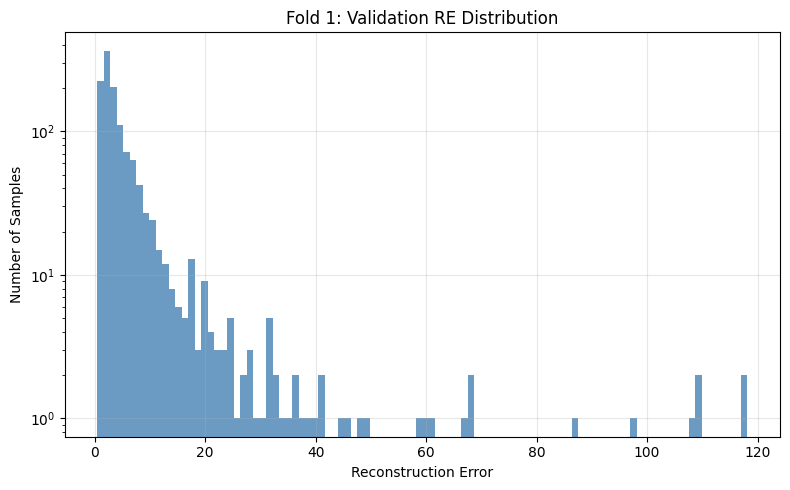

Computing RE on unseen dataset (d_d)...


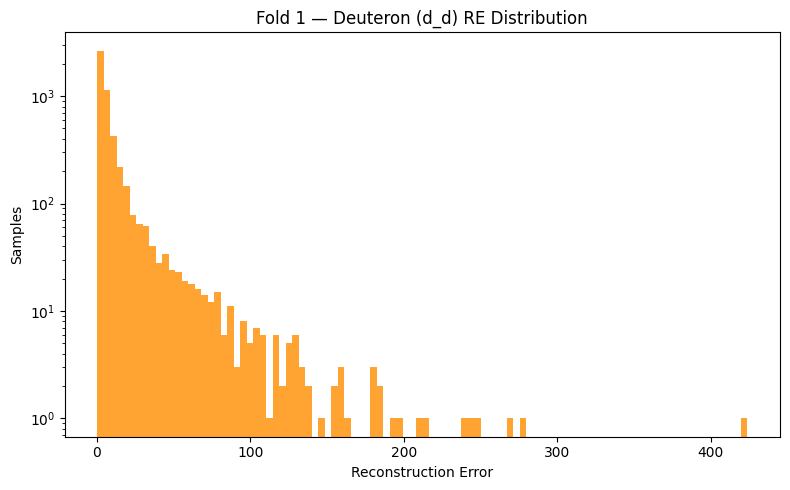


===== Fold 2/5 =====
Epoch 1/50: Train=59.2068, Val=33.6869
Epoch 2/50: Train=28.4081, Val=24.4137
Epoch 3/50: Train=20.9275, Val=17.4564
Epoch 4/50: Train=16.9502, Val=16.1173
Epoch 5/50: Train=14.6787, Val=14.3211
Epoch 6/50: Train=12.7669, Val=12.7261
Epoch 7/50: Train=12.0685, Val=11.6777
Epoch 8/50: Train=10.7635, Val=10.3070
Epoch 9/50: Train=9.7092, Val=10.8857
Epoch 10/50: Train=9.1992, Val=11.1578
Epoch 11/50: Train=8.8548, Val=9.2018
Epoch 12/50: Train=8.2485, Val=8.7493
Epoch 13/50: Train=7.7940, Val=8.8457
Epoch 14/50: Train=7.5685, Val=8.5773
Epoch 15/50: Train=7.3274, Val=7.8071
Epoch 16/50: Train=6.6528, Val=8.0978
Epoch 17/50: Train=6.3793, Val=7.7467
Epoch 18/50: Train=6.3281, Val=7.9747
Epoch 19/50: Train=6.2423, Val=7.1934
Epoch 20/50: Train=5.9518, Val=7.2255
Epoch 21/50: Train=6.1887, Val=7.6863
Epoch 22/50: Train=5.7024, Val=7.1306
Epoch 23/50: Train=5.4448, Val=7.4408
Epoch 24/50: Train=5.3898, Val=6.4009
Epoch 25/50: Train=5.3140, Val=6.6749
Epoch 26/50: Train=

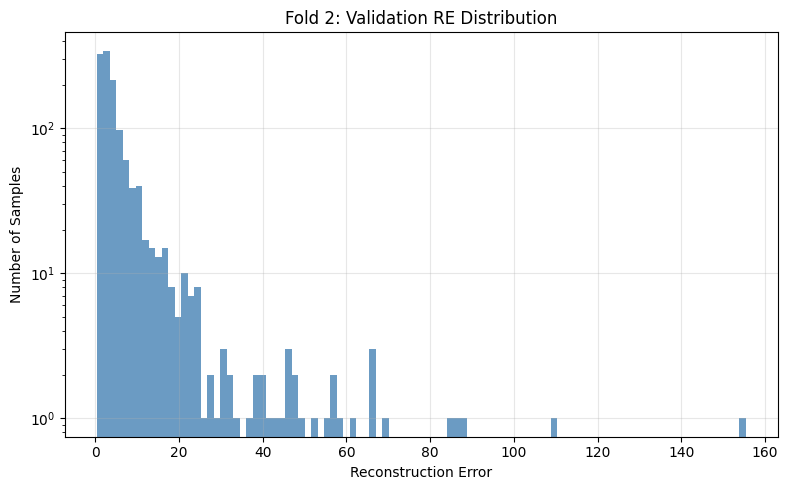

Computing RE on unseen dataset (d_d)...


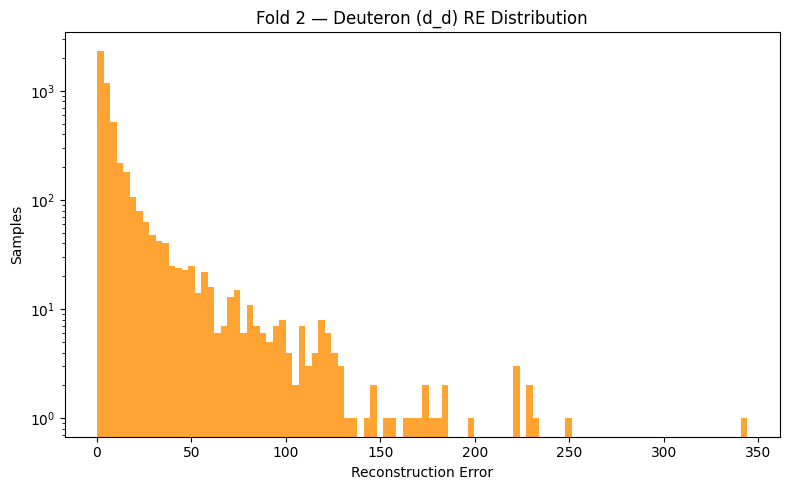


===== Fold 3/5 =====
Epoch 1/50: Train=58.6287, Val=34.7306
Epoch 2/50: Train=28.1056, Val=22.8793
Epoch 3/50: Train=19.7148, Val=17.6855
Epoch 4/50: Train=16.9447, Val=15.9500
Epoch 5/50: Train=14.2176, Val=13.3468
Epoch 6/50: Train=12.0915, Val=12.1703
Epoch 7/50: Train=11.4425, Val=11.4262
Epoch 8/50: Train=10.4481, Val=10.4438
Epoch 9/50: Train=9.7528, Val=10.2966
Epoch 10/50: Train=8.7509, Val=9.2977
Epoch 11/50: Train=8.4325, Val=9.1936
Epoch 12/50: Train=8.0136, Val=9.0547
Epoch 13/50: Train=7.3067, Val=8.3295
Epoch 14/50: Train=6.8021, Val=8.1158
Epoch 15/50: Train=6.8275, Val=8.1996
Epoch 16/50: Train=6.6063, Val=8.2406
Epoch 17/50: Train=6.8345, Val=8.7132
Epoch 18/50: Train=6.4665, Val=7.5713
Epoch 19/50: Train=6.0552, Val=7.8609
Epoch 20/50: Train=5.7230, Val=7.0934
Epoch 21/50: Train=5.3431, Val=6.9870
Epoch 22/50: Train=5.7278, Val=7.1246
Epoch 23/50: Train=5.4258, Val=7.3331
Epoch 24/50: Train=5.3269, Val=6.7155
Epoch 25/50: Train=5.0247, Val=7.6317
Epoch 26/50: Train=5

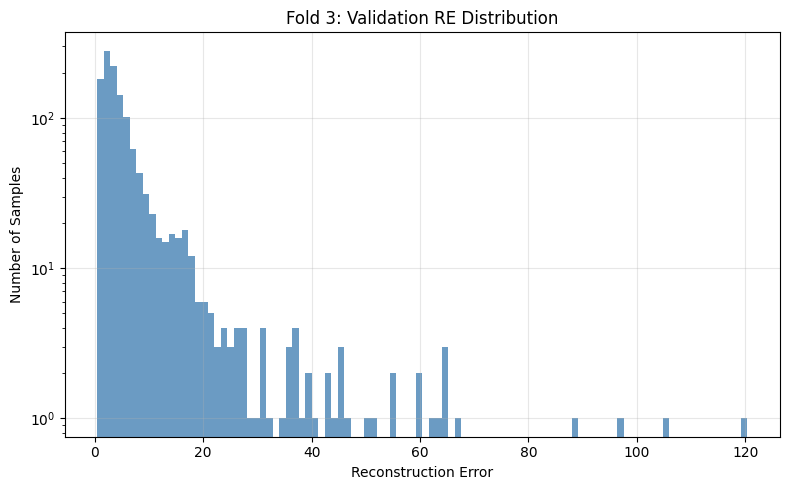

Computing RE on unseen dataset (d_d)...


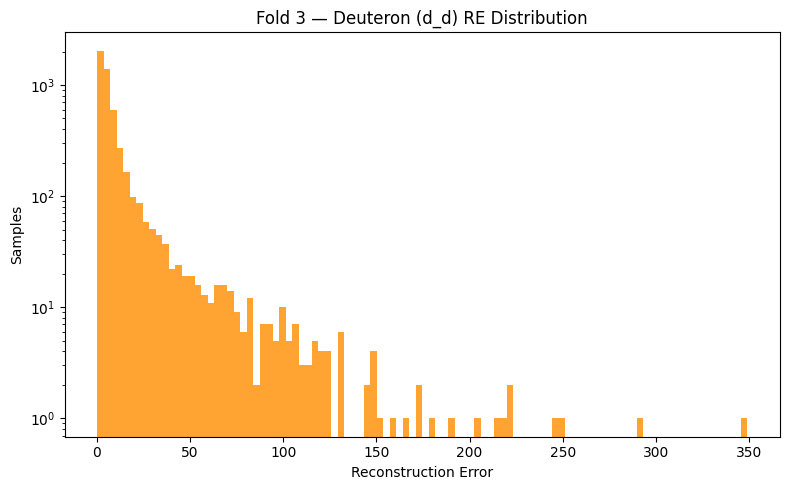


===== Fold 4/5 =====
Epoch 1/50: Train=56.7485, Val=33.3398
Epoch 2/50: Train=27.0776, Val=22.3884
Epoch 3/50: Train=19.9476, Val=18.2269
Epoch 4/50: Train=15.9874, Val=15.7605
Epoch 5/50: Train=14.1125, Val=13.3564
Epoch 6/50: Train=12.1717, Val=12.2571
Epoch 7/50: Train=10.9149, Val=11.6967
Epoch 8/50: Train=10.2375, Val=11.1547
Epoch 9/50: Train=9.6905, Val=10.0907
Epoch 10/50: Train=8.9979, Val=9.3536
Epoch 11/50: Train=8.3084, Val=9.5092
Epoch 12/50: Train=8.1697, Val=9.1157
Epoch 13/50: Train=7.5148, Val=8.4120
Epoch 14/50: Train=7.0985, Val=8.4320
Epoch 15/50: Train=7.0974, Val=8.0130
Epoch 16/50: Train=6.7615, Val=8.4004
Epoch 17/50: Train=6.5582, Val=7.8756
Epoch 18/50: Train=6.2168, Val=7.6309
Epoch 19/50: Train=5.8468, Val=7.2384
Epoch 20/50: Train=5.4355, Val=7.4301
Epoch 21/50: Train=5.5380, Val=7.4685
Epoch 22/50: Train=5.5672, Val=7.4711
Epoch 23/50: Train=5.6016, Val=7.5346
Epoch 24/50: Train=5.3880, Val=7.1264
Epoch 25/50: Train=5.0674, Val=6.8376
Epoch 26/50: Train=4

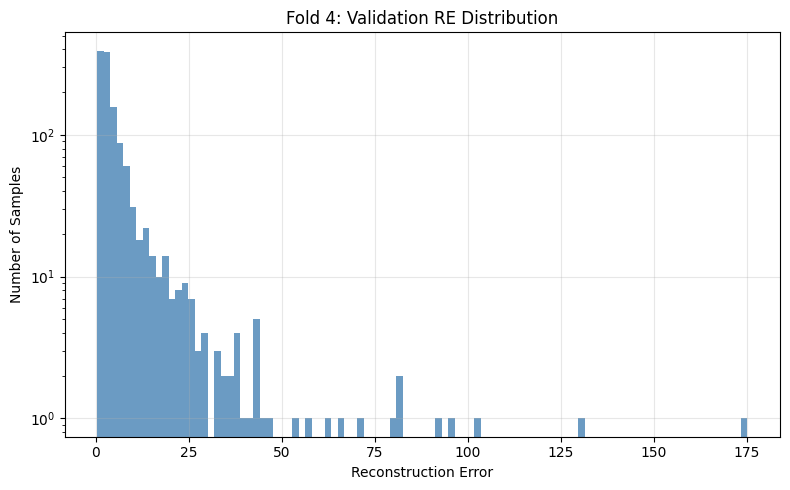

Computing RE on unseen dataset (d_d)...


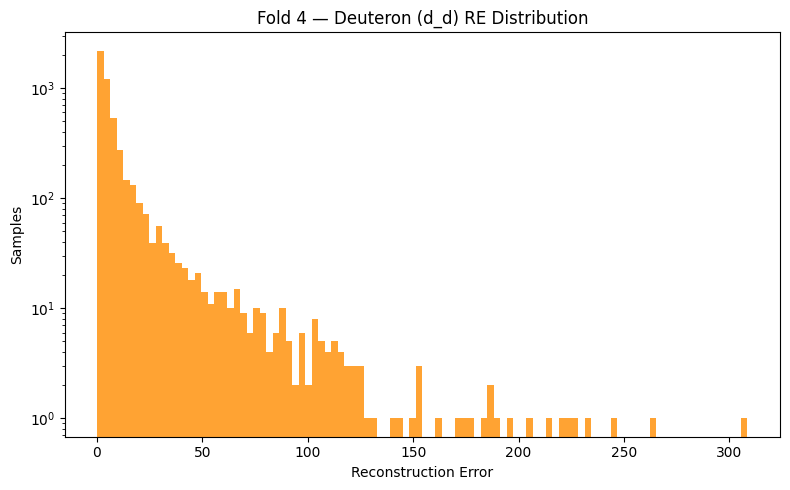


===== Fold 5/5 =====
Epoch 1/50: Train=58.1886, Val=34.8086
Epoch 2/50: Train=27.9595, Val=22.3506
Epoch 3/50: Train=20.2181, Val=17.5972
Epoch 4/50: Train=16.4449, Val=15.4794
Epoch 5/50: Train=13.9320, Val=13.8287
Epoch 6/50: Train=12.3763, Val=13.0490
Epoch 7/50: Train=11.1032, Val=11.4076
Epoch 8/50: Train=10.5875, Val=10.8273
Epoch 9/50: Train=9.7658, Val=9.9113
Epoch 10/50: Train=8.6971, Val=9.2179
Epoch 11/50: Train=8.5044, Val=9.9421
Epoch 12/50: Train=8.0090, Val=8.3836
Epoch 13/50: Train=7.5457, Val=7.7931
Epoch 14/50: Train=7.3554, Val=8.2351
Epoch 15/50: Train=6.8009, Val=7.9273
Epoch 16/50: Train=6.6438, Val=7.6613
Epoch 17/50: Train=6.5154, Val=7.4182
Epoch 18/50: Train=6.2897, Val=7.2463
Epoch 19/50: Train=5.9670, Val=7.2232
Epoch 20/50: Train=6.0229, Val=7.2459
Epoch 21/50: Train=5.7296, Val=7.0630
Epoch 22/50: Train=5.6763, Val=6.5650
Epoch 23/50: Train=5.4026, Val=7.0721
Epoch 24/50: Train=5.3307, Val=6.6211
Epoch 25/50: Train=5.2884, Val=6.6731
Epoch 26/50: Train=4.

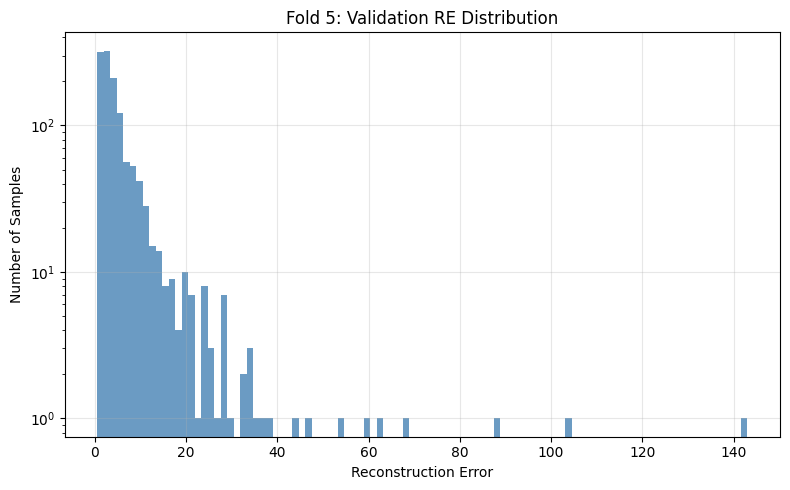

Computing RE on unseen dataset (d_d)...


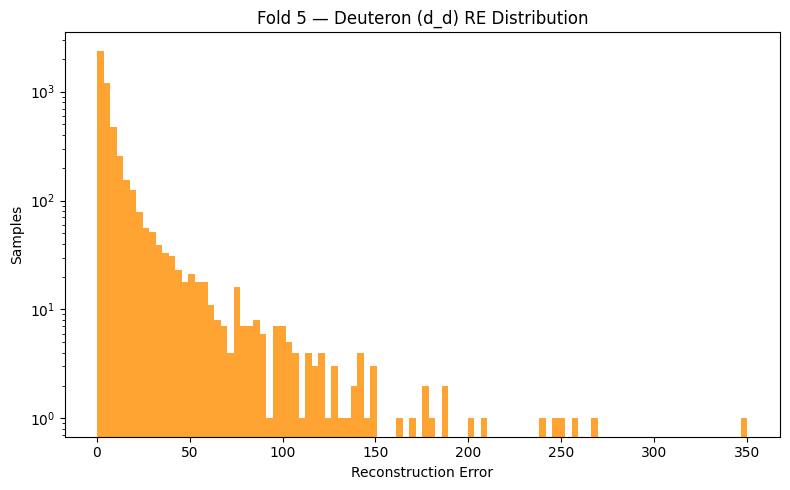

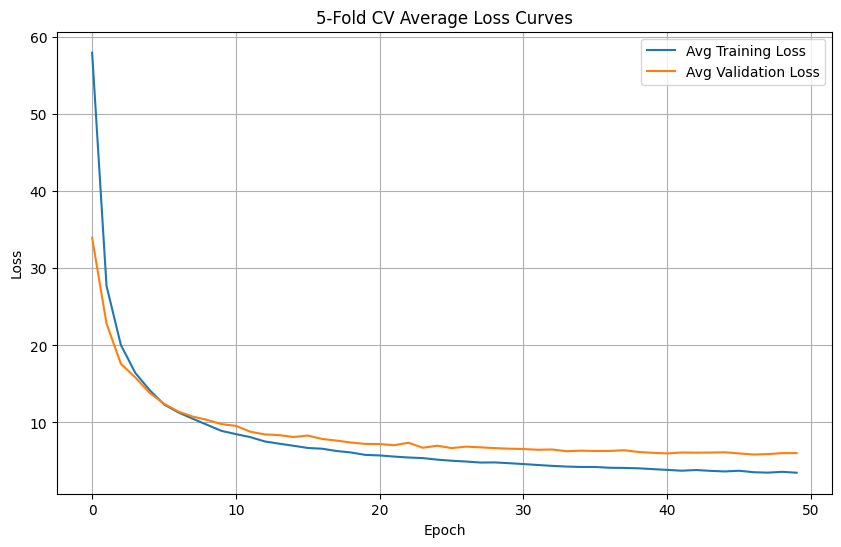

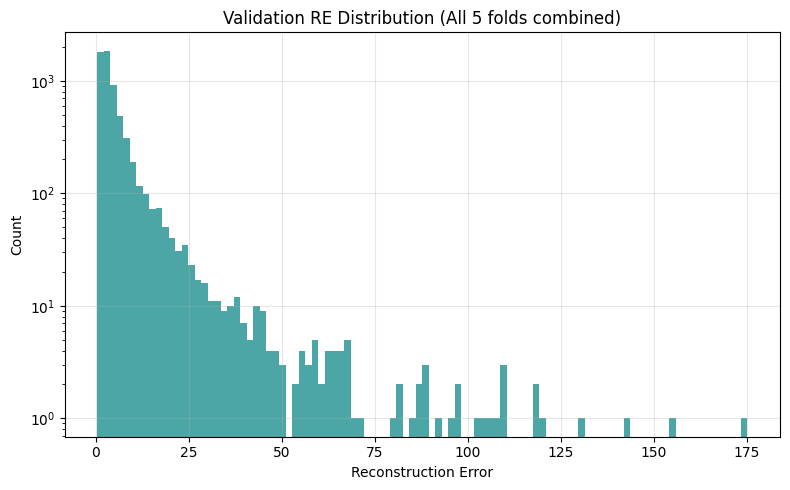

In [28]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=16).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, H, W = X_val_np.shape
    recon_all = np.empty((N, H, W), dtype=np.float32)

    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (d_d) ======
    # ============================================================

    print("Computing RE on unseen dataset (d_d)...")

    Xd_np = d_d.astype(np.float32)       # unseen data
    N, H, W = Xd_np.shape
    recon_all_d = np.empty((N, H, W), dtype=np.float32)
    latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_d[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_d[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_d_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2))
    fold_REs_d_d.append(RE_d_d)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_d_d, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d_d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

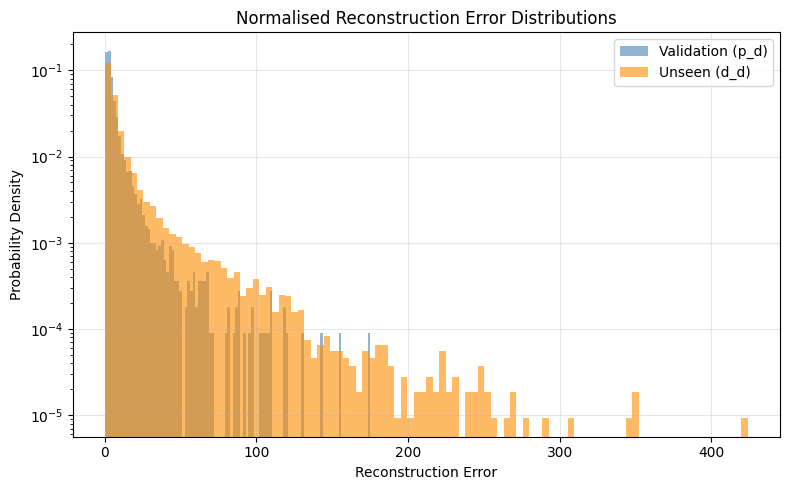

Validation mean RE: 6.081 ± 10.130
Unseen (d_d) mean RE: 10.442 ± 20.853


In [ ]:
all_RE_val = np.concatenate(fold_REs)
all_RE_d_d  = np.concatenate(fold_REs_d_d)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_d_d, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (d_d)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.3f} ± {all_RE_val.std():.3f}")
print(f"Unseen (d_d) mean RE: {all_RE_d_d.mean():.3f} ± {all_RE_d_d.std():.3f}")

Inference device: mps
recon_all.shape: (5033, 64, 64)
latent_vectors.shape: (5033, 16)
RE_per_sample.shape: (5033,)


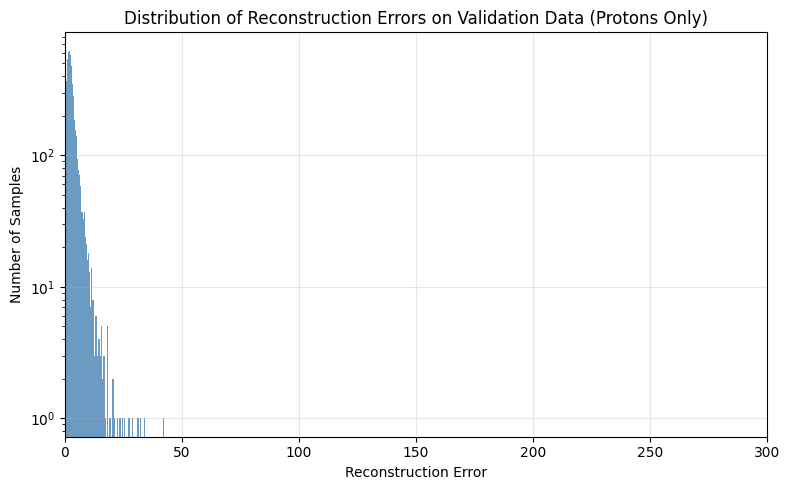

In [71]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (1258, 64, 64)
latent_vectors.shape: (1258, 16)
RE_per_sample.shape: (1258,)


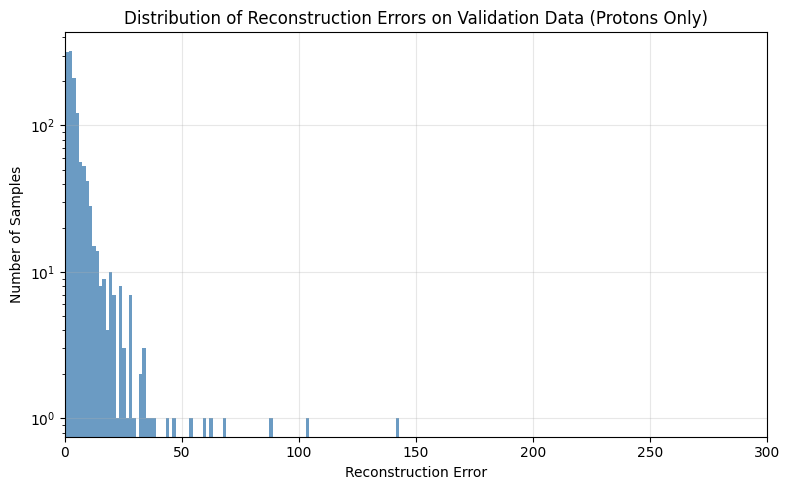

In [72]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all.shape: (5115, 64, 64)
latent_vectors.shape: (5115, 16)
RE_per_sample_d.shape: (5115,)


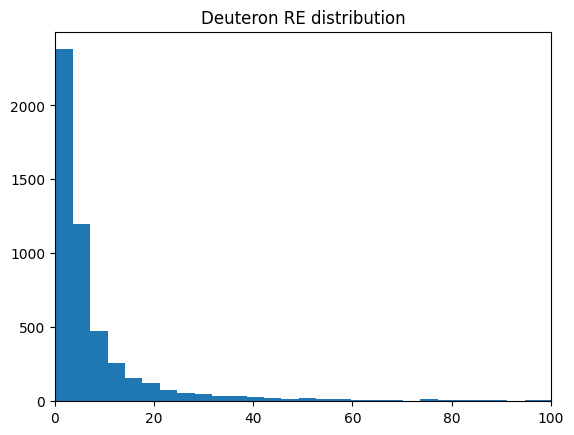

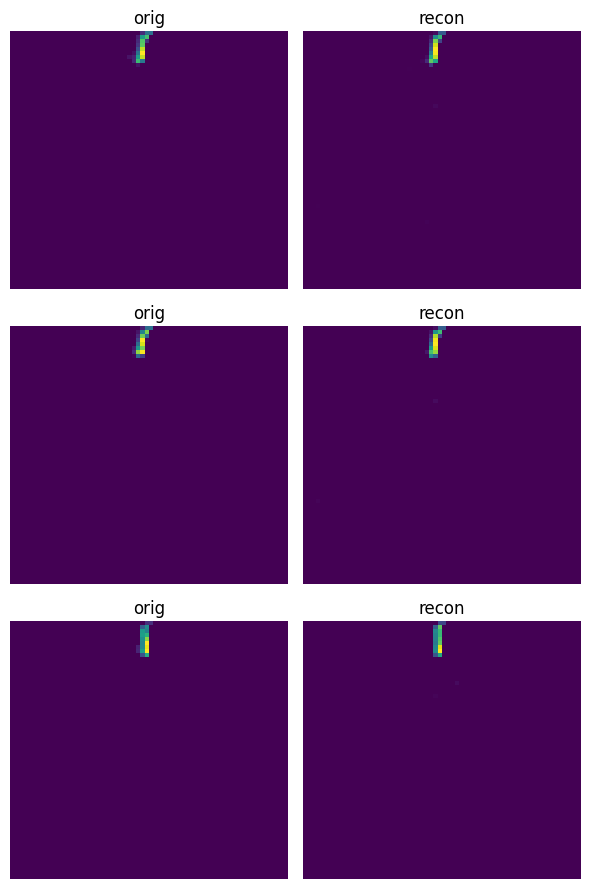

In [73]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d_d.astype(np.float32)          # (N, H, W)
N, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all = np.empty((N, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all[i:j] = out.cpu().numpy()

        enc = model.encoder(xb.unsqueeze(1))    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_d[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all - Xd_np) ** 2).mean(axis=(1, 2))

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors_d.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

plt.figure()
plt.hist(RE_per_sample_d, bins=100)
plt.xlim(0, 100)
plt.title("Deuteron RE distribution")
plt.show()

k = min(3, N)
fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
for ii in range(k):
    axs[ii,0].imshow(Xd_np[ii], cmap='viridis', aspect='auto'); axs[ii,0].set_title("orig"); axs[ii,0].axis('off')
    axs[ii,1].imshow(recon_all[ii], cmap='viridis', aspect='auto'); axs[ii,1].set_title("recon"); axs[ii,1].axis('off')
plt.tight_layout()
plt.show()

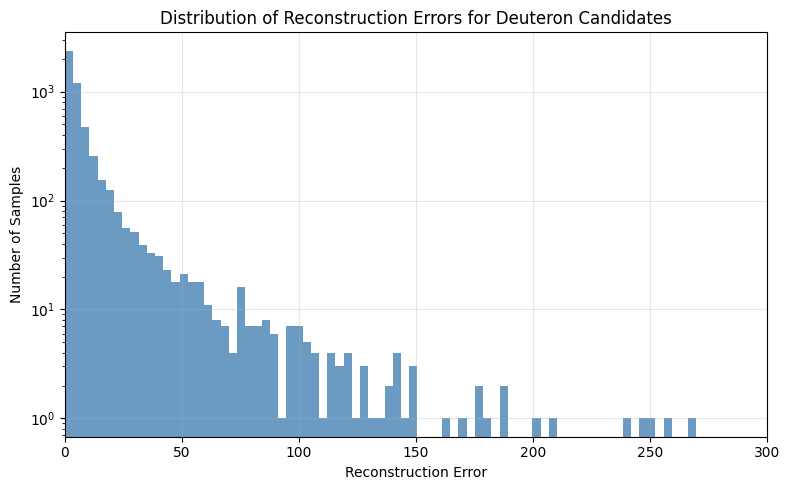

In [74]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_d, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors for Deuteron Candidates")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

In [80]:
latent_vectors_d.shape, RE_per_sample_d.shape

((5115, 16), (5115,))

In [81]:
latent_vectors.shape, RE_per_sample.shape

((5033, 16), (5033,))

In [82]:
latent_vectors_val.shape, RE_per_sample_val.shape

((1258, 16), (1258,))

In [78]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

# Run t-SNE directly (16-D input is fine)
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

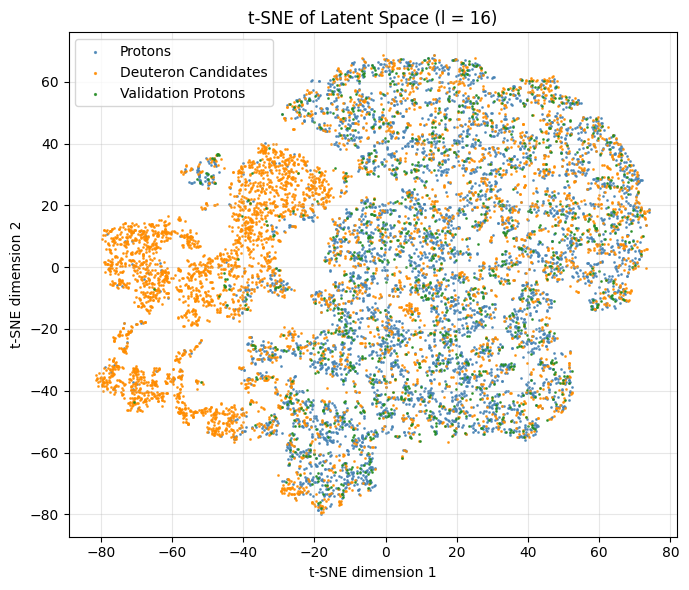

In [83]:
%matplotlib inline

# Plot with three colours
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Deuteron Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

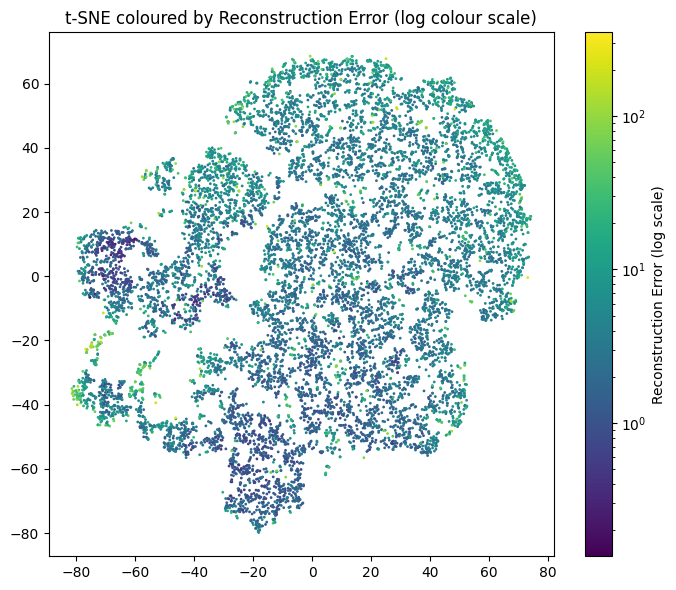

In [ ]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_d, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# low error regions and high error regions in deuteron candidates?
# overlap with proton latent vectors?
# separation with proton latent vectors

In [102]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


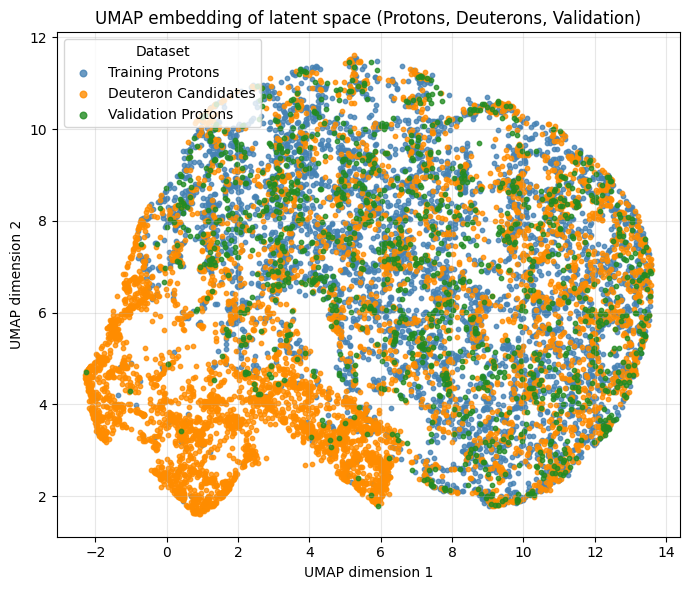

In [103]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


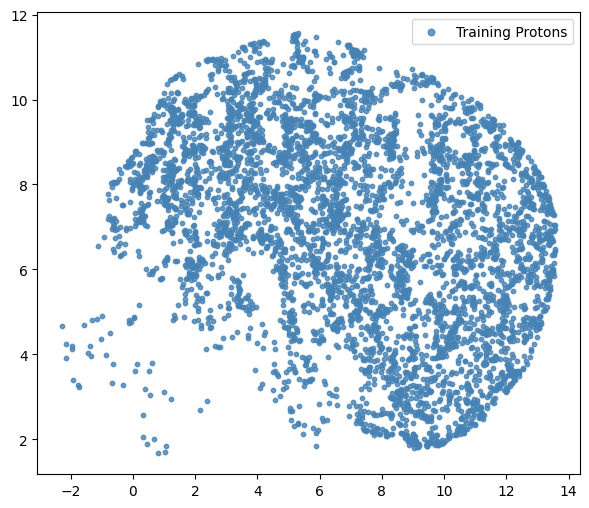

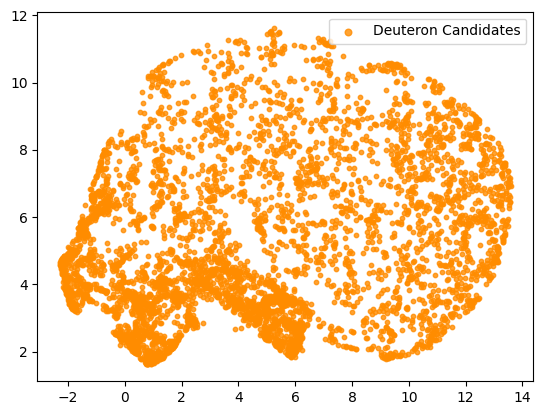

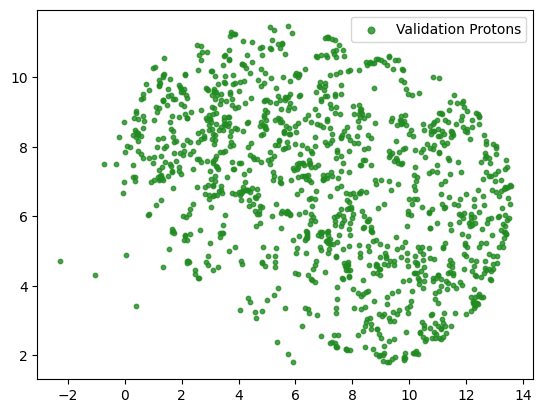

In [131]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


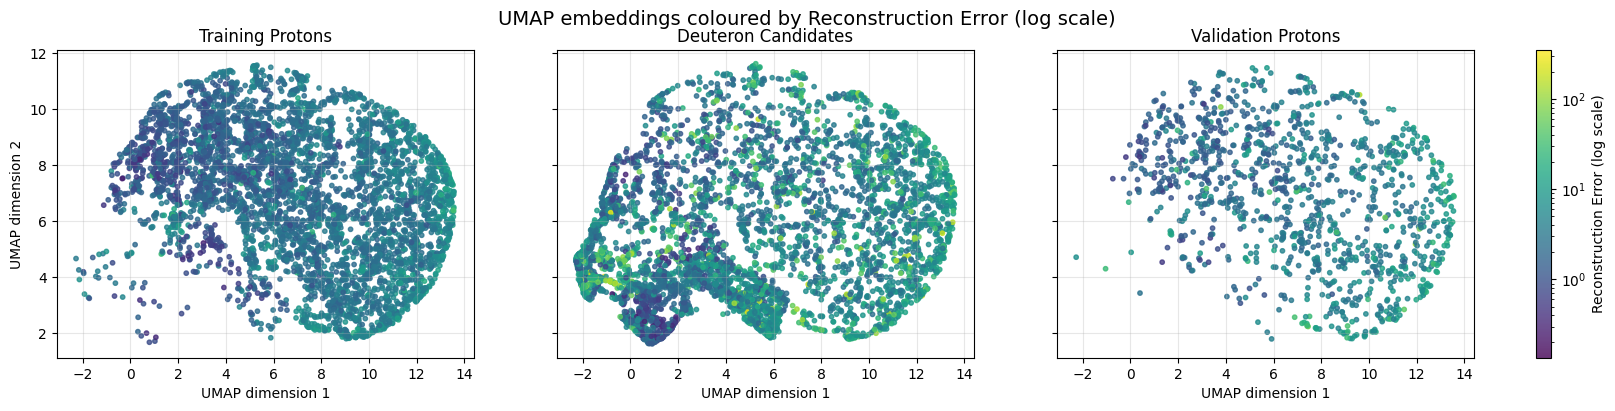

In [ ]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


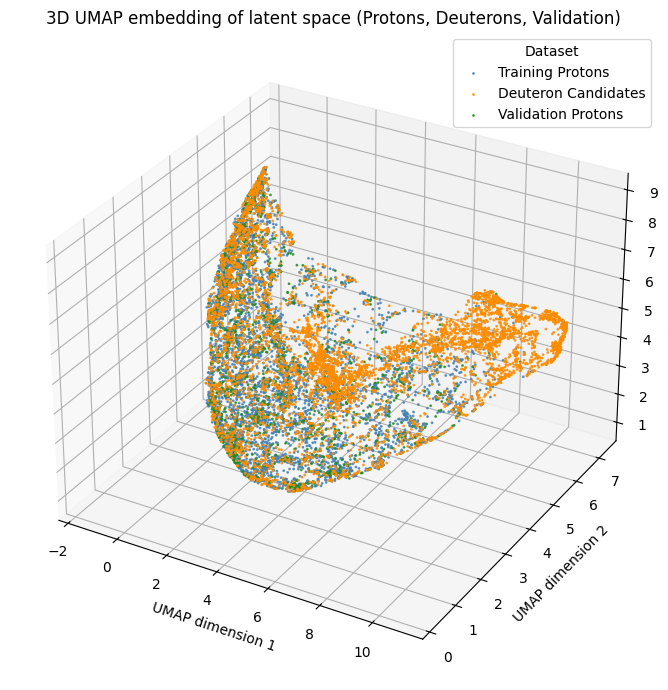

In [114]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D

umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    mask = (labels == i)
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8,
        label=name
    )

ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding of latent space (Protons, Deuterons, Validation)")
ax.legend(title="Dataset", loc="upper right")

# ax.view_init(elev=45, azim=45)         # azim 0 along x, 90 along y

plt.tight_layout()
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


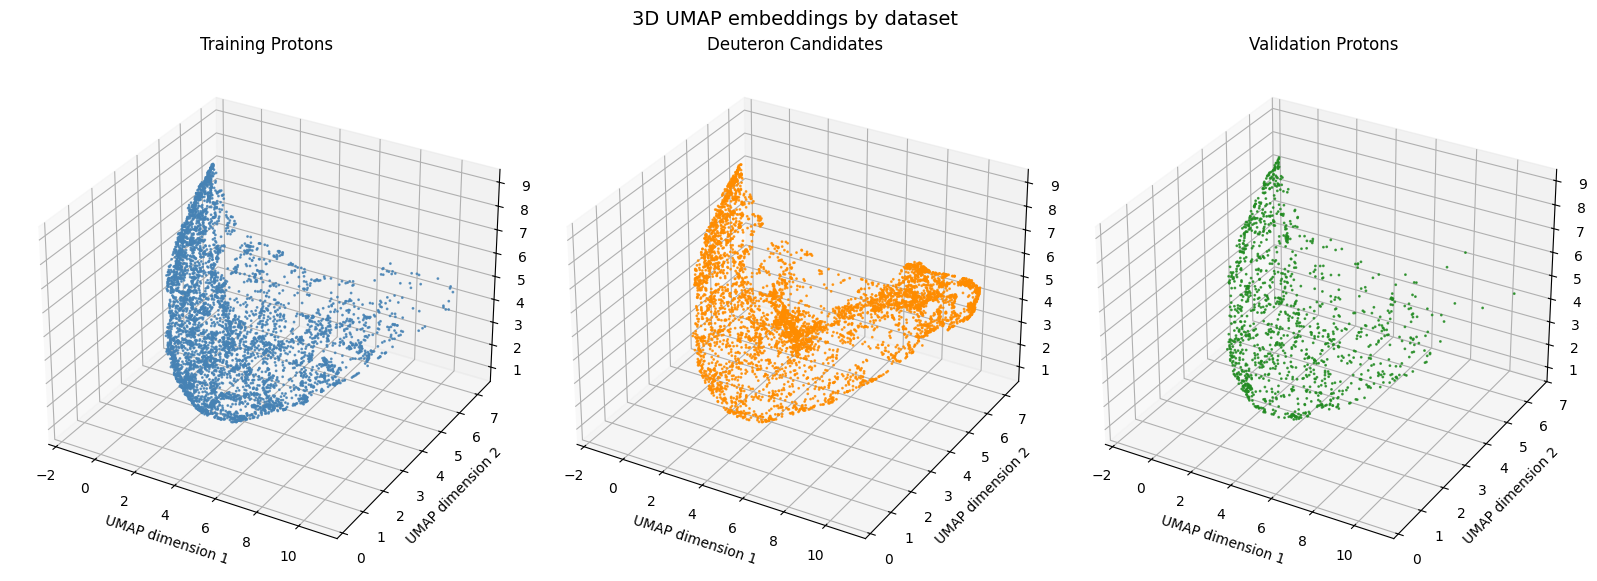

In [138]:
umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(16, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8
    )
    ax.set_title(name)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  

fig.suptitle("3D UMAP embeddings by dataset", fontsize=14)
plt.tight_layout()
plt.show()


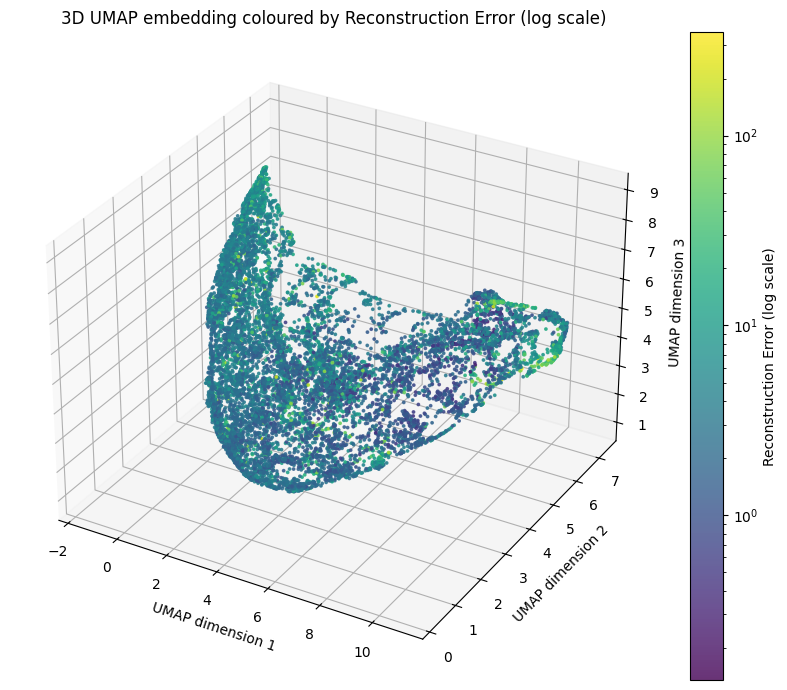

In [120]:
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot coloured by reconstruction error
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=RE_all,
    cmap='viridis',
    norm=mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max()),
    s=3,
    alpha=0.8
)

# Axis labels and title
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding coloured by Reconstruction Error (log scale)")

# Colour bar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

plt.tight_layout()
plt.show()


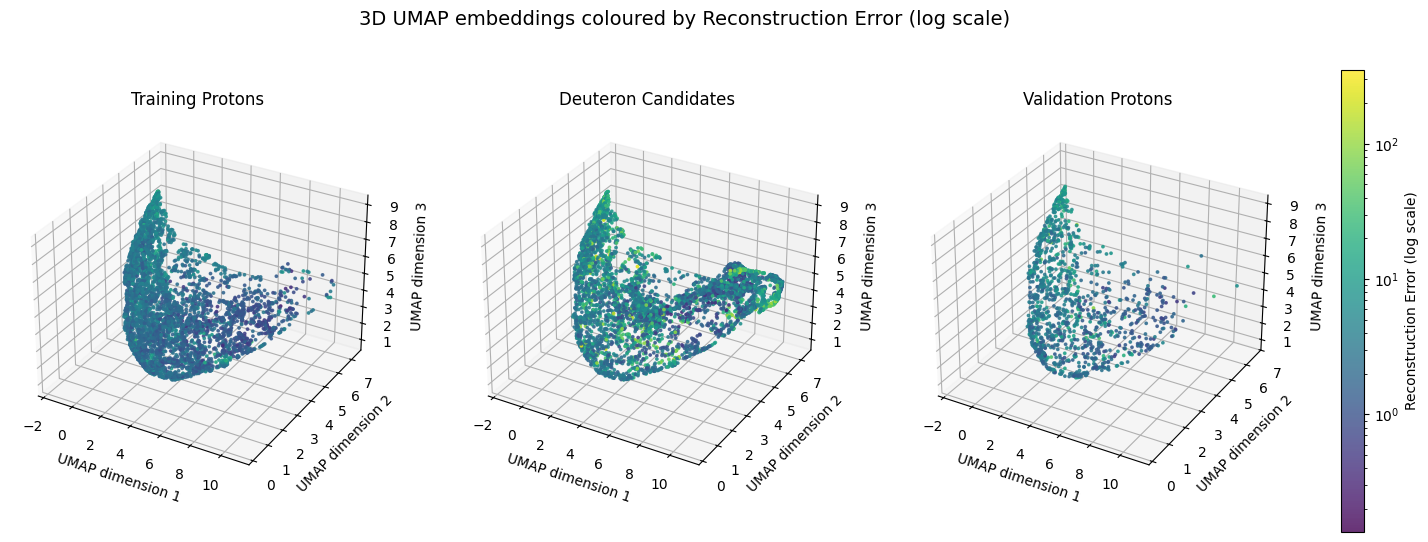

In [147]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assume: embedding (3D UMAP), RE_all (reconstruction errors), labels (0,1,2)
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# Shared normalisation and colormap for all plots
norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    sc = ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        c=RE_all[mask],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  # consistent 3D orientation

# Shared colour bar for all subplots
cbar = fig.colorbar(sc, ax=fig.get_axes(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("3D UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()
